# Lab 2 — Linear Regression

**What this lab covers:**
- Simple linear regression (1 feature → 1 target)
- Multiple linear regression (multiple features → 1 target)
- Model evaluation: MSE, RMSE, R², Adjusted R²
- Train/validation split and model selection
- Why more features ≠ better model

**The sklearn workflow (same every time):**
```python
from sklearn.linear_model import LinearRegression
model = LinearRegression()      # 1. Instantiate
model.fit(X_train, y_train)     # 2. Fit (learn parameters)
y_pred = model.predict(X_test)  # 3. Predict
score = model.score(X_test, y_test)  # 4. Evaluate
```

---

## Part 1: Simple Linear Regression — Toy Example

We want to learn a model: $\hat{y} = w_0 + w_1 x$

- $w_0$ = intercept (bias term)
- $w_1$ = coefficient (slope)
- sklearn learns these by minimising the mean squared error

### Step 1.1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib
matplotlib.style.use('ggplot')

### Step 1.2: Define X and y

In [2]:
X = np.array([5, 7, 9, 11, 13, 15])
y = np.array([11, 14, 20, 24, 29, 31])

### Step 1.3: Plot to check if linear model makes sense

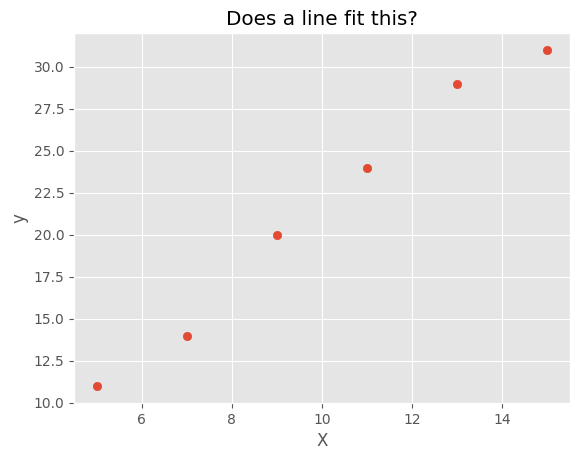

In [3]:
# If the data looks roughly linear, linear regression is a reasonable choice
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Does a line fit this?')
plt.show()

### Step 1.4: Check correlation

In [4]:
# Correlation coefficient: ranges from -1 to 1
# Close to 1 or -1 = strong linear relationship
# Close to 0 = no linear relationship
print(np.corrcoef(X, y))
# The off-diagonal value (0.993) shows very high correlation

[[1.         0.99322298]
 [0.99322298 1.        ]]


### Step 1.5: Reshape X for sklearn

**Critical concept:** sklearn expects X to be a 2D array (matrix) where:
- Each **row** = one data point
- Each **column** = one feature

y stays 1D (one value per data point).

In [5]:
# X is currently 1D: shape (6,)
print("Before reshape:", X.shape, "ndim:", X.ndim)

# reshape(-1, 1) means: as many rows as needed, 1 column
X = X.reshape(-1, 1)

print("After reshape:", X.shape, "ndim:", X.ndim)
# Now shape is (6, 1) — 6 rows, 1 feature column

Before reshape: (6,) ndim: 1
After reshape: (6, 1) ndim: 2


### Step 1.6: Build the model

In [6]:
from sklearn.linear_model import LinearRegression

# Instantiate — no constructor parameters needed for basic linear regression
model = LinearRegression()

# Fit — this is where sklearn learns w0 and w1
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 1.7: Read the learned parameters

After fitting, the model stores:
- `model.coef_` → array of weights [w1, w2, ...] (one per feature)
- `model.intercept_` → w0 (the bias/intercept)

In [7]:
w0 = model.intercept_
w1 = model.coef_[0]

print(f"w0 (intercept): {w0:.4f}")
print(f"w1 (slope):     {w1:.4f}")
print(f"\nModel: ŷ = {w0:.4f} + {w1:.4f} × x")

w0 (intercept): 0.2143
w1 (slope):     2.1286

Model: ŷ = 0.2143 + 2.1286 × x


### Step 1.8: Make predictions

In [8]:
# Method 1: manually using the equation
manual_pred = w0 + w1 * X

# Method 2: use model.predict() — always prefer this
# .predict() expects the same 2D shape as .fit()
pred = model.predict(X)

# They give the same result
print("Manual:", manual_pred.flatten())
print("Predict:", pred)

Manual: [10.85714286 15.11428571 19.37142857 23.62857143 27.88571429 32.14285714]
Predict: [10.85714286 15.11428571 19.37142857 23.62857143 27.88571429 32.14285714]


### Step 1.9: Evaluate the model

**Regression metrics:**
- **MSE** (Mean Squared Error): average of (actual - predicted)². Lower = better. Scale depends on data.
- **RMSE** (Root MSE): √MSE. In the same units as y. Lower = better.
- **R²** (R-squared): proportion of variance explained. 1.0 = perfect, 0 = useless. Can be negative.

In [9]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score as r2

print(f"MSE:  {mse(y, pred):.4f}")
print(f"RMSE: {np.sqrt(mse(y, pred)):.4f}")
print(f"R²:   {r2(y, pred):.4f}")

# model.score() is a shortcut — for LinearRegression it returns R²
print(f"model.score(): {model.score(X, y):.4f}")

MSE:  0.7238
RMSE: 0.8508
R²:   0.9865
model.score(): 0.9865


### Step 1.10: Plot the line of best fit

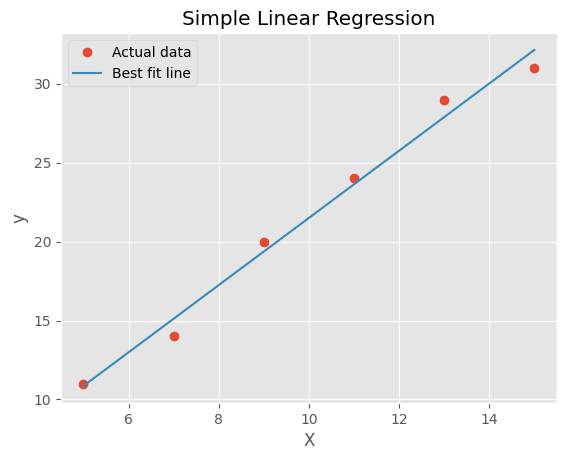

In [10]:
plt.plot(X, y, 'o', label='Actual data')
plt.plot(X, pred, label='Best fit line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

---
## Part 2: Simple Linear Regression — Car Value Example

Predict car value from age. Note: multiple cars at the same age have different values
(variance the model can't capture).

### Step 2.1: Define data and reshape

In [11]:
X = np.array([5, 4, 6, 5, 5, 5, 6, 6, 2, 7, 7])
y = np.array([85, 103, 70, 82, 89, 98, 66, 95, 169, 70, 48])

# Remember: X must be 2D for sklearn
X = X.reshape(-1, 1)

### Step 2.2: Build and fit model

In [12]:
model = LinearRegression()
model.fit(X, y)

w0 = model.intercept_
w1 = model.coef_[0]
print(f"Model: ŷ = {w0:.2f} + ({w1:.2f}) × age")
# Negative coefficient makes sense — older cars are worth less

Model: ŷ = 195.47 + (-20.26) × age


### Step 2.3: Predict and evaluate

In [13]:
pred = model.predict(X)

print(f"MSE:  {mse(y, pred):.2f}")
print(f"RMSE: {np.sqrt(mse(y, pred)):.2f}")
print(f"R²:   {r2(y, pred):.4f}")

MSE:  129.41
RMSE: 11.38
R²:   0.8534


### Step 2.4: Plot

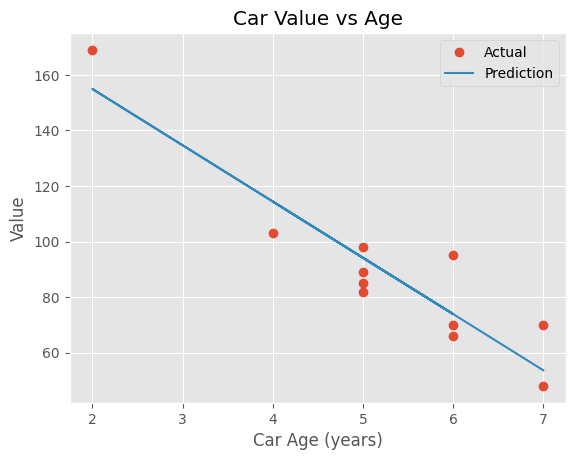

In [14]:
plt.plot(X, y, 'o', label='Actual')
plt.plot(X, pred, label='Prediction')
plt.xlabel('Car Age (years)')
plt.ylabel('Value')
plt.title('Car Value vs Age')
plt.legend()
plt.show()

---
## Part 3: Model Selection — Why Validation Matters

**Key concept:** Evaluating on the training data gives overly optimistic results.
We need a **validation set** (data the model has never seen) to honestly assess performance.

**Why validation and not test?** Because we're making a *decision* about which model is best.
A test set should only be used once, at the very end.

We generate synthetic data with:
- x1: strongly predictive
- x2: weakly predictive
- x3: pure noise (no predictive value)

### Step 3.1: Generate synthetic data

In [15]:
np.random.seed(0)
n = 500

x1 = np.random.normal(size=n)          # strong predictor
x2 = np.random.normal(size=n) * 0.5    # weak predictor
x3 = np.random.normal(size=n)          # noise — no relationship to y

# True relationship: y = 3*x1 + 0.5*x2 + random noise
# x3 is NOT in the true equation
y = 3 * x1 + 0.5 * x2 + np.random.normal(scale=0.5, size=n)

# Stack into feature matrix: each column is a feature
X = np.column_stack([x1, x2, x3])
print(f"X shape: {X.shape}  (500 samples, 3 features)")

X shape: (500, 3)  (500 samples, 3 features)


### Step 3.2: Train/validation split

In [16]:
from sklearn.model_selection import train_test_split

# 70% training, 30% validation
# random_state ensures reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")

Training: 350 samples
Validation: 150 samples


### Step 3.3: Compare models with different feature subsets

We train 4 models, each using different columns of X:
- Model A: x1 only (strong predictor)
- Model B: x2 only (weak predictor)
- Model C: x1 + x2 (both real predictors)
- Model D: x1 + x2 + x3 (includes noise)

**Column indexing:** `X[:, [0]]` selects column 0 as a 2D array. `X[:, [0, 1]]` selects columns 0 and 1.

In [17]:
# Model A: x1 only (strong predictor)
model_a = LinearRegression().fit(X_train[:, [0]], y_train)
print("Model A (x1 only):")
print(f"  Train R²: {model_a.score(X_train[:, [0]], y_train):.3f}")
print(f"  Val R²:   {r2(y_val, model_a.predict(X_val[:, [0]])):.3f}")

Model A (x1 only):
  Train R²: 0.963
  Val R²:   0.976


In [18]:
# Model B: x2 only (weak predictor)
model_b = LinearRegression().fit(X_train[:, [1]], y_train)
print("Model B (x2 only):")
print(f"  Train R²: {model_b.score(X_train[:, [1]], y_train):.3f}")
print(f"  Val R²:   {r2(y_val, model_b.predict(X_val[:, [1]])):.3f}")

Model B (x2 only):
  Train R²: 0.001
  Val R²:   -0.056


In [19]:
# Model C: x1 + x2 (both real predictors)
model_c = LinearRegression().fit(X_train[:, [0, 1]], y_train)
print("Model C (x1 + x2):")
print(f"  Train R²: {model_c.score(X_train[:, [0, 1]], y_train):.3f}")
print(f"  Val R²:   {r2(y_val, model_c.predict(X_val[:, [0, 1]])):.3f}")

Model C (x1 + x2):
  Train R²: 0.971
  Val R²:   0.978


In [20]:
# Model D: all features including noise
model_d = LinearRegression().fit(X_train, y_train)
print("Model D (x1 + x2 + x3 noise):")
print(f"  Train R²: {model_d.score(X_train, y_train):.3f}")
print(f"  Val R²:   {r2(y_val, model_d.predict(X_val)):.3f}")

Model D (x1 + x2 + x3 noise):
  Train R²: 0.972
  Val R²:   0.977


### Step 3.4: Takeaway from model comparison

**Key observations:**
- Model C (x1 + x2) should have the best validation R² — it uses exactly the real features
- Model D adds x3 (noise) — training R² goes up slightly, but validation R² doesn't improve or gets worse
- Adding irrelevant features can hurt generalisation
- **Always evaluate on validation data, never just training data**

---
## Part 4: Real Data — mtcars (Automobile MPG Prediction)

Predict miles per gallon (mpg) from car characteristics.

### Step 4.1: Load and explore the data

In [21]:
dfcars = pd.read_csv('mtcars.csv')
dfcars = dfcars.rename(columns={'Unnamed: 0': 'name'})
print(dfcars.head())
print(f"\nShape: {dfcars.shape}")
print(f"\nColumns: {list(dfcars.columns)}")

                name   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  

Shape: (32, 12)

Columns: ['name', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']


### Step 4.2: Train/validation split

In [22]:
# Split the data BEFORE looking at any models
from sklearn.model_selection import train_test_split

# We'll define X and y after choosing features,
# but split the whole dataframe first for consistency
train_df, val_df = train_test_split(dfcars, test_size=0.3, random_state=42)
print(f"Training: {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")

Training: 22 rows
Validation: 10 rows


### Step 4.3: Choose a predictor — look at correlations and scatter plots

Pick a feature that has a strong correlation with mpg.

In [23]:
# Check correlation of all numeric columns with mpg
print("Correlation with mpg:")
print(dfcars.corr(numeric_only=True)['mpg'].sort_values())

Correlation with mpg:
wt     -0.867659
cyl    -0.852162
disp   -0.847551
hp     -0.776168
carb   -0.550925
qsec    0.418684
gear    0.480285
am      0.599832
vs      0.664039
drat    0.681172
mpg     1.000000
Name: mpg, dtype: float64


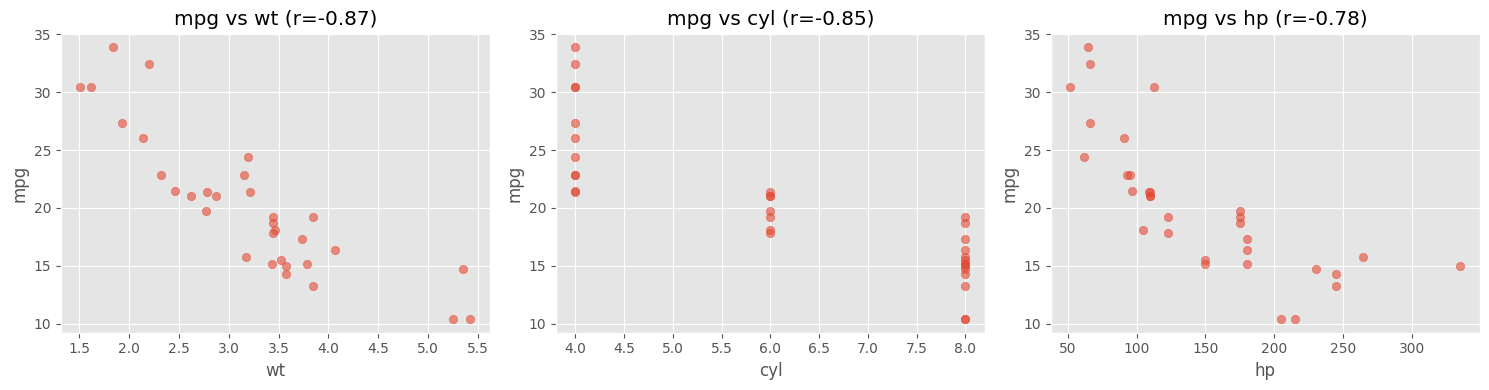

In [24]:
# Scatter plots of the most correlated features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['wt', 'cyl', 'hp']):
    ax.scatter(dfcars[col], dfcars['mpg'], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('mpg')
    ax.set_title(f'mpg vs {col} (r={dfcars[col].corr(dfcars["mpg"]):.2f})')

plt.tight_layout()
plt.show()

### Step 4.4: Simple linear regression — 1 predictor (wt)

Weight (wt) typically has the strongest negative correlation with mpg.

In [25]:
# Define features and target from train/val splits
X_train_1 = train_df[['wt']]
X_val_1 = val_df[['wt']]
y_train = train_df['mpg']
y_val = val_df['mpg']

# Fit
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)

# Predict
pred_train_1 = model_1.predict(X_train_1)
pred_val_1 = model_1.predict(X_val_1)

# Evaluate
print("Simple LR (wt only):")
print(f"  Train — MSE: {mse(y_train, pred_train_1):.2f}, R²: {r2(y_train, pred_train_1):.3f}")
print(f"  Val   — MSE: {mse(y_val, pred_val_1):.2f}, R²: {r2(y_val, pred_val_1):.3f}")

# Coefficients
print(f"\n  Equation: mpg = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f}) × wt")

Simple LR (wt only):
  Train — MSE: 8.63, R²: 0.758
  Val   — MSE: 9.09, R²: 0.733

  Equation: mpg = 37.04 + (-5.36) × wt


/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


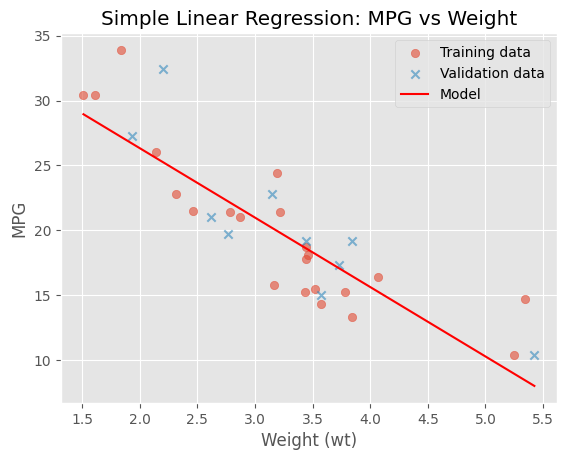

In [26]:
# Plot: actual data + regression line
plt.scatter(train_df['wt'], y_train, label='Training data', alpha=0.6)
plt.scatter(val_df['wt'], y_val, label='Validation data', alpha=0.6, marker='x')

# Draw the regression line across the range of wt values
wt_range = np.linspace(dfcars['wt'].min(), dfcars['wt'].max(), 100).reshape(-1, 1)
plt.plot(wt_range, model_1.predict(wt_range), 'r-', label='Model')

plt.xlabel('Weight (wt)')
plt.ylabel('MPG')
plt.title('Simple Linear Regression: MPG vs Weight')
plt.legend()
plt.show()

### Step 4.5: Multiple linear regression — 2 predictors

In [27]:
# Add a second predictor (hp)
X_train_2 = train_df[['wt', 'hp']]
X_val_2 = val_df[['wt', 'hp']]

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

pred_val_2 = model_2.predict(X_val_2)

print("Multiple LR (wt + hp):")
print(f"  Train — R²: {model_2.score(X_train_2, y_train):.3f}")
print(f"  Val   — MSE: {mse(y_val, pred_val_2):.2f}, R²: {r2(y_val, pred_val_2):.3f}")
print(f"\n  Equation: mpg = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f}) × wt + ({model_2.coef_[1]:.4f}) × hp")

Multiple LR (wt + hp):
  Train — R²: 0.826
  Val   — MSE: 6.36, R²: 0.813

  Equation: mpg = 37.08 + (-3.80) × wt + (-0.0349) × hp


### Step 4.6: Multiple linear regression — 3 predictors

In [28]:
# Add a third predictor
X_train_3 = train_df[['wt', 'hp', 'disp']]
X_val_3 = val_df[['wt', 'hp', 'disp']]

model_3 = LinearRegression()
model_3.fit(X_train_3, y_train)

pred_val_3 = model_3.predict(X_val_3)

print("Multiple LR (wt + hp + disp):")
print(f"  Train — R²: {model_3.score(X_train_3, y_train):.3f}")
print(f"  Val   — MSE: {mse(y_val, pred_val_3):.2f}, R²: {r2(y_val, pred_val_3):.3f}")

Multiple LR (wt + hp + disp):
  Train — R²: 0.826
  Val   — MSE: 6.35, R²: 0.813


### Step 4.7: Compare all mtcars models

Check: does adding more features always help?

In [29]:
# Summary comparison
print(f"{'Model':<25} {'Train R²':>10} {'Val R²':>10} {'Val MSE':>10}")
print('-' * 55)
print(f"{'1 feature (wt)':<25} {model_1.score(X_train_1, y_train):>10.3f} {r2(y_val, pred_val_1):>10.3f} {mse(y_val, pred_val_1):>10.2f}")
print(f"{'2 features (wt+hp)':<25} {model_2.score(X_train_2, y_train):>10.3f} {r2(y_val, pred_val_2):>10.3f} {mse(y_val, pred_val_2):>10.2f}")
print(f"{'3 features (wt+hp+disp)':<25} {model_3.score(X_train_3, y_train):>10.3f} {r2(y_val, pred_val_3):>10.3f} {mse(y_val, pred_val_3):>10.2f}")

Model                       Train R²     Val R²    Val MSE
-------------------------------------------------------
1 feature (wt)                 0.758      0.733       9.09
2 features (wt+hp)             0.826      0.813       6.36
3 features (wt+hp+disp)        0.826      0.813       6.35


---
## Part 5: Diabetes Dataset (Built into sklearn)

This dataset is already normalised (mean≈0, std≈1 for each feature).
We'll look at:
- Fitting on all features
- Adjusted R² (penalises extra features)
- Dropping unhelpful features

### Step 5.1: Load and explore

In [30]:
from sklearn import datasets

diabetes = datasets.load_diabetes()
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"Features: {list(diabetes.feature_names)}")
print(f"Shape: {data.shape}")
print(f"\nTarget (y): disease progression measure")
data.head()

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape: (442, 10)

Target (y): disease progression measure


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


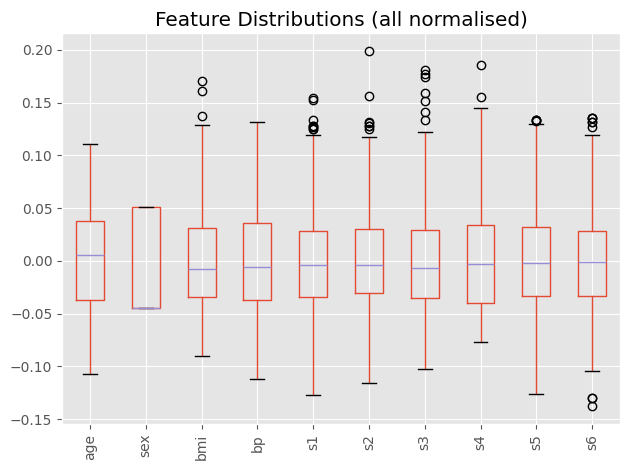

In [31]:
# Box plot to see feature ranges — they're all normalised to similar scale
data.boxplot(rot=90)
plt.title('Feature Distributions (all normalised)')
plt.tight_layout()
plt.show()

### Step 5.2: Fit on all features

In [32]:
X = data
lr = LinearRegression()
lr.fit(X, y)

r_squared = lr.score(X, y)
print(f"R²: {r_squared:.4f}")

R²: 0.5177


### Step 5.3: Adjusted R²

R² always increases (or stays the same) when you add features, even useless ones.
**Adjusted R²** penalises for number of features:

$$R^2_{adj} = 1 - (1 - R^2) \times \frac{n - 1}{n - p - 1}$$

where n = number of samples, p = number of features.

In [33]:
n = len(y)
p = X.shape[1]
adjusted_r2 = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R²:          {r_squared:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"(n={n} samples, p={p} features)")

R²:          0.5177
Adjusted R²: 0.5066
(n=442 samples, p=10 features)


### Step 5.4: Inspect coefficients — which features matter?

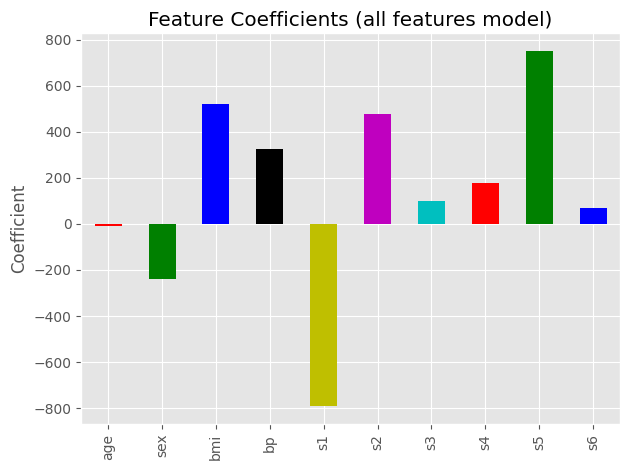


Intercept: 152.13

Coefficients:
    age:   -10.01
    sex:  -239.82
    bmi:   519.85
     bp:   324.38
     s1:  -792.18
     s2:   476.74
     s3:   101.04
     s4:   177.06
     s5:   751.27
     s6:    67.63


In [34]:
# Plot coefficients as a bar chart
coef = pd.Series(lr.coef_, index=diabetes.feature_names)
coef.plot(kind='bar', color=list('rgbkymc' * 2))
plt.ylabel('Coefficient')
plt.title('Feature Coefficients (all features model)')
plt.tight_layout()
plt.show()

print(f"\nIntercept: {lr.intercept_:.2f}")
print("\nCoefficients:")
for name, c in zip(diabetes.feature_names, lr.coef_):
    print(f"  {name:>5}: {c:>8.2f}")

### Step 5.5: Drop a weak feature and compare

If 'age' has a small coefficient, removing it might give a simpler model
with similar or better adjusted R².

In [35]:
# Remove 'age' column
X_no_age = data.drop(['age'], axis=1)

lr2 = LinearRegression()
lr2.fit(X_no_age, y)

r2_no_age = lr2.score(X_no_age, y)
adj_r2_no_age = 1 - (1 - r2_no_age) * (n - 1) / (n - X_no_age.shape[1] - 1)

print(f"All features   — R²: {r_squared:.4f}, Adjusted R²: {adjusted_r2:.4f}")
print(f"Without 'age'  — R²: {r2_no_age:.4f}, Adjusted R²: {adj_r2_no_age:.4f}")
print("\nR² is nearly identical, but adjusted R² slightly better without 'age'")
print("→ Simpler model, similar performance = generally preferred")

All features   — R²: 0.5177, Adjusted R²: 0.5066
Without 'age'  — R²: 0.5177, Adjusted R²: 0.5077

R² is nearly identical, but adjusted R² slightly better without 'age'
→ Simpler model, similar performance = generally preferred


---
## Summary — Key Takeaways for the Exam

### Linear Regression Essentials
```python
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Build model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
pred = model.predict(X_val)
print(f'MSE: {mean_squared_error(y_val, pred)}')
print(f'R²: {r2_score(y_val, pred)}')

# Inspect
print(model.coef_)       # weights
print(model.intercept_)  # bias
```

### Data Shape Requirements
- **X** must be 2D: `(n_samples, n_features)`. Use `.reshape(-1, 1)` for single feature.
- **y** must be 1D: `(n_samples,)`

### Evaluation Metrics (Regression)
| Metric | Meaning | Better |
|--------|---------|--------|
| MSE | Mean Squared Error | Lower |
| RMSE | √MSE (same units as y) | Lower |
| R² | Variance explained | Closer to 1 |
| Adjusted R² | R² penalised for extra features | Closer to 1 |